# RAPTOR: Recursive Abstractive Processing for Tree-Organized Retrieval

[RAPTOR](https://arxiv.org/pdf/2401.18059.pdf) 논문은 문서의 색인 생성 및 검색에 대한 흥미로운 접근 방식을 제시합니다.

[테디노트 논문 요약글(노션)](https://teddylee777.notion.site/RAPTOR-e835d306fc664dc2ad76191dee1cd859?pvs=4)

- `leafs` 는 가장 low-level 의 시작 문서 집합입니다. 이 문서들은 임베딩되어 클러스터링됩니다.
- 그런 다음 클러스터는 유사한 문서들 간의 정보를 더 높은 수준(더 추상적인)으로 요약합니다.

이 과정은 재귀적으로 수행되어, 원본 문서(`leafs`)에서 더 추상적인 요약으로 이어지는 "트리"를 형성합니다.

`leafs`는 다음과 같은 문서들로 구성될 수 있습니다.

- 단일 문서에서의 텍스트 청크(논문에서 보여준 것처럼)
- 전체 문서(아래에서 보여주는 것처럼)

이번 튜토리얼에서는 긴 문서(PDF) 에 대해서 RAPTOR 방법론을 적용해 보도록 하겠습니다.


## 실습에 활용한 문서

소프트웨어정책연구소(SPRi) - 2023년 12월호

- 저자: 유재흥(AI정책연구실 책임연구원), 이지수(AI정책연구실 위촉연구원)
- 링크: https://spri.kr/posts/view/23669
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

_실습을 위해 다운로드 받은 파일을 `data` 폴더로 복사해 주시기 바랍니다_


## 환경 설정

**추가 패키지 설치**

아래 주석을 해제하고 실행하여 추가 패키지를 설치 후 진행해 주세요.

In [1]:
# !pip install -U umap-learn
# 참고: umap-learn 외에도 이 노트북은 scikit-learn(GaussianMixture), faiss-cpu(FAISS)가 필요합니다.
# 이미 기본편 실습 환경이라면 대부분 설치되어 있을 가능성이 높습니다.


상단의 **restart** 버튼을 눌러 재시작 한 뒤 다시 처음부터 진행해 주세요.

In [2]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv
import warnings

# 경고 메시지 무시
warnings.filterwarnings("ignore")

# API 키 정보 로드
load_dotenv()

True

In [3]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH12-RAPTOR")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH12-RAPTOR


## 데이터 전처리

`doc`은 PDF 파일입니다. 토큰 수는 100 토큰 미만에서 10,000 토큰 이상까지 다양합니다.

웹 문서에서 텍스트 데이터를 추출하고, 텍스트의 토큰 수를 계산하여 히스토그램으로 시각화합니다.

문서의 페이지수: 23


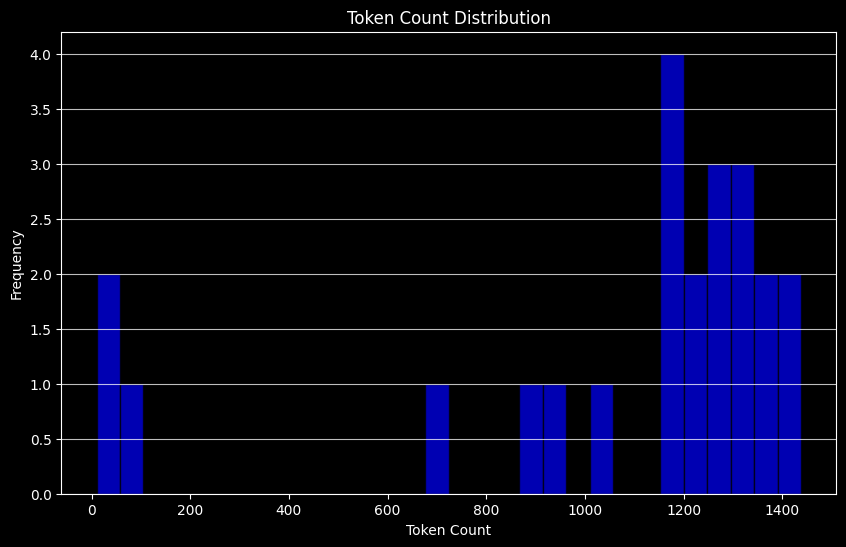

In [4]:
from langchain_community.document_loaders import PDFPlumberLoader
import tiktoken
import matplotlib.pyplot as plt


# 텍스트를 토큰 단위로 인코딩했을 때 몇 개의 토큰이 되는지 계산하는 함수
# (텍스트 길이를 "글자 수"가 아니라 "LLM이 실제로 처리하는 단위(토큰)"로 재는 것이 핵심)
def num_tokens_from_string(string: str, encoding_name: str):
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens


# 문서 로드(Load Documents)
# PDFPlumberLoader는 PDF를 "페이지 단위" 문서 리스트로 반환합니다.
# 즉 docs[0]은 1페이지, docs[1]은 2페이지... 이런 식으로 아직 RAG용 청크가 아닙니다.
loader = PDFPlumberLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
print(f"문서의 페이지수: {len(docs)}")

# 문서 텍스트
docs_texts = [d.page_content for d in docs]

# 각 문서(페이지)에 대한 토큰 수 계산
# → 페이지마다 텍스트 양이 들쭉날쭉하다는 것을 미리 확인하는 목적
counts = [num_tokens_from_string(d, "cl100k_base") for d in docs_texts]

# 토큰 수의 히스토그램을 그립니다.
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Token Count Distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# 히스토그램을 표시합니다.
plt.show()


문서 텍스트를 정렬합니다. 이때 메타데이터의 `source` 를 기준으로 정렬한 뒤, 모든 문서를 연결합니다.

In [5]:
# 문서(페이지)를 출처 메타데이터(source, 보통 파일 경로+페이지 정보) 기준으로 정렬합니다.
# 페이지 순서를 보장해서 문서 전체 맥락이 뒤섞이지 않게 하려는 목적입니다.
d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))

# 페이지별로 흩어져 있던 텍스트를 "하나의 긴 문자열"로 합칩니다.
# RAPTOR는 이후 이 긴 텍스트를 다시 작은 단위(leaf)로 쪼개는 방식으로 시작하기 때문에,
# 일단 페이지 경계를 없애고 하나의 연속된 문서로 만드는 단계입니다.
concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)

print(
    "전체 토큰 수: %s"  # 모든 문맥에서의 토큰 수를 출력합니다.
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)


전체 토큰 수: 24131


`RecursiveCharacterTextSplitter`를 사용하여 텍스트를 분할합니다.

In [6]:
# 텍스트 분할을 위한 코드
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 기준 토큰수
# RAPTOR의 leaf(최하위 노드) 하나의 크기를 결정하는 값입니다.
# 100 토큰은 일반 RAG(보통 500~1000 토큰)보다 훨씬 작은데,
# RAPTOR는 이 작은 leaf들을 클러스터링해서 요약본(상위 노드)을 만드는 구조이기 때문에
# leaf 자체는 세밀하게 쪼개 놓는 편이 클러스터링 품질에 유리합니다.
chunk_size = 100

# 텍스트 분할기 초기화 (토큰 기준으로 자르기 위해 tiktoken 인코더 사용)
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=chunk_size, chunk_overlap=0
)

# 주어진 텍스트를 분할 → 이 결과가 RAPTOR 트리의 "leaf_texts"가 됩니다.
texts_split = text_splitter.split_text(concatenated_content)


다음으로는 분할된 chunk 들을 임베딩하여 vector store 에 저장합니다.

In [7]:
from langchain_openai import OpenAIEmbeddings
from langchain.embeddings import CacheBackedEmbeddings
from langchain.storage import LocalFileStore

# cache 저장 경로 지정
# CacheBackedEmbeddings는 "같은 텍스트를 다시 임베딩할 때 API를 재호출하지 않고 캐시에서 꺼내 쓰는" 래퍼입니다.
# RAPTOR는 leaf 임베딩 + 여러 레벨의 요약 임베딩까지 임베딩 호출이 잦기 때문에,
# 실습을 여러 번 재실행할 걸 대비해 캐시를 걸어두면 비용/시간을 아낄 수 있습니다.
store = LocalFileStore("./cache/")

# embeddings 인스턴스를 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", disallowed_special=())

# CacheBackedEmbeddings 인스턴스를 생성
# (실제 임베딩 로직은 그대로 두고, 캐시 조회/저장 기능만 감싸는 것 — 오늘 얘기한 "래퍼" 패턴과 동일)
cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
    embeddings, store, namespace=embeddings.model
)


## 모델 설정

In [8]:
from langchain_teddynote.messages import stream_response
from langchain_openai import ChatOpenAI


# llm 모델 초기화
# temperature=0으로 설정한 이유: 이 LLM은 답변 생성뿐 아니라
# "클러스터 요약문 생성"에도 반복적으로 쓰입니다. 요약 단계에서 창의성보다는
# 일관되고 결정적인(같은 입력 → 비슷한 출력) 결과가 나오는 게 트리 품질에 유리합니다.
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)


## 트리 구축

트리 구축에서의 클러스터링 접근 방식에 대한 주요 개요입니다.

**GMM (가우시안 혼합 모델)**

- 다양한 클러스터에 걸쳐 데이터 포인트의 분포를 모델링합니다.
- 모델의 베이지안 정보 기준(BIC)을 평가하여 최적의 클러스터 수를 결정합니다.

**UMAP (Uniform Manifold Approximation and Projection)**

- 클러스터링을 지원합니다.
- 고차원 데이터의 차원을 축소합니다.
- UMAP은 데이터 포인트의 유사성에 기반하여 자연스러운 그룹화를 강조하는 데 도움을 줍니다.

**지역 및 전역 클러스터링**

- 데이터를 저차원으로 차원 축소하여 클러스터링을 수행합니다.

**임계값 설정**

- GMM의 맥락에서 클러스터 멤버십을 결정하기 위해 적용됩니다.
- 확률 분포를 기반으로 합니다(데이터 포인트를 ≥ 1 클러스터에 할당).

---

GMM 및 임계값 설정에 대한 코드는 아래 두 출처에서 언급된 Sarthi et al의 것입니다. 

**참조**

- [원본 저장소](https://github.com/parthsarthi03/raptor/blob/master/raptor/cluster_tree_builder.py)
- [소소한 조정](https://github.com/run-llama/llama_index/blob/main/llama-index-packs/llama-index-packs-raptor/llama_index/packs/raptor/clustering.py)

### 차원 축소

`global_cluster_embeddings`

- 입력된 임베딩 벡터를 전역적으로 차원 축소하기 위해 UMAP을 적용합니다. 전역적으로 차원을 축소한 결과물을 얻어 추후 클러스터링에 활용합니다.

**과정**

- n_neighbors: UMAP에 사용될 이웃(neighbor) 수를 정합니다. 데이터 포인트 하나를 이해할 때 주변 데이터 포인트 개수를 나타냅니다. 입력이 없으면 데이터 개수에 따라 자동으로 계산합니다.
- umap.UMAP(...)를 사용하여, 고차원 임베딩을 dim 차원으로 축소합니다.
- 축소된 벡터들은 전역적(global)인 구조 파악에 도움이 되는 저차원 표현입니다.

---

`local_cluster_embeddings`

- 선택한 데이터 부분집합에 대해 로컬(국소적) 차원 축소를 수행합니다.

**과정**

- 글로벌 차원 축소와 유사하지만, 로컬 차원 축소는 이미 한 번 전역 클러스터링을 통해 추출한 특정 그룹(글로벌 클러스터) 내 데이터에 대해 다시 UMAP을 적용합니다.
- 이 과정은 전역적으로 파악된 큰 구조 안에서 더 세밀한 클러스터 구조를 파악하는 데 도움이 됩니다.

In [9]:
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import umap

# [수정] 원본(langchain.prompts)은 구버전 경로입니다.
# 최신 LangChain에서 프롬프트/파서 계열은 langchain_core 아래로 옮겨졌으므로 이 경로를 사용합니다.
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from sklearn.mixture import GaussianMixture

RANDOM_SEED = 42  # 재현성을 위한 고정된 시드 값


def global_cluster_embeddings(
    embeddings: np.ndarray,
    dim: int,
    n_neighbors: Optional[int] = None,
    metric: str = "cosine",
) -> np.ndarray:
    """[Global 차원 축소]
    전체 임베딩(예: leaf 청크 전부, 혹은 특정 레벨의 요약문 전부)을 대상으로
    UMAP을 적용해 고차원 벡터를 저차원(dim)으로 압축합니다.

    의도: 임베딩은 보통 수백~수천 차원이라 "차원의 저주" 때문에 클러스터링이 잘 안 먹힙니다.
    클러스터링 전에 먼저 차원을 확 줄여서 GMM이 그룹 구조를 더 잘 찾게 도와주는 전처리 단계입니다.
    "Global"이라는 이름은 이 축소가 "전체 데이터 집합"을 기준으로 이루어진다는 뜻입니다
    (이후 local_cluster_embeddings는 이미 한 번 나뉜 하위 그룹 안에서만 다시 이 작업을 반복합니다).

    Args:
        embeddings (np.ndarray): 차원을 축소할 임베딩 벡터들
        dim (int): 축소할 차원의 수
        n_neighbors (Optional[int], optional): UMAP에서 사용할 이웃의 수. 기본값은 None으로, 이 경우 데이터 크기에 따라 자동 계산됨
        metric (str, optional): 거리 계산에 사용할 메트릭. 기본값은 "cosine"

    Returns:
        np.ndarray: 차원이 축소된 임베딩 벡터들
    """
    # 이웃 수 계산 (데이터 개수의 제곱근 정도로 자동 설정 — UMAP의 일반적인 경험적 기준)
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)

    # UMAP 적용
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int, num_neighbors: int = 10, metric: str = "cosine"
) -> np.ndarray:
    """[Local 차원 축소]
    global_cluster_embeddings로 이미 한 번 큰 그룹(global cluster)으로 나뉜 뒤,
    그 그룹 하나에 속한 데이터만 떼어내서 다시 UMAP을 적용하는 함수입니다.

    의도: "법률 vs 기술"처럼 스케일이 큰 차이와, "LLM vs 이미지생성"처럼 스케일이 작은 차이를
    하나의 클러스터링으로 동시에 잘 구분하기는 어렵습니다. 그래서 먼저 큰 틀(global)로 나누고,
    그 안에서 다시 세밀하게(local) 나누는 2단계 구조를 씁니다.
    num_neighbors 기본값(10)이 global의 자동 계산 방식과 다른 이유는,
    이미 데이터가 작은 하위 그룹으로 좁혀진 상태라 이웃 수를 고정된 작은 값으로 둬도 충분하기 때문입니다.

    [수정 안내] 원본 노트북에는 이 함수 본문이 `return`만 있고 실제 UMAP 호출이 비어 있어
    항상 None을 반환하는 상태였습니다(미완성 코드로 추정). global_cluster_embeddings와
    동일한 로직에 num_neighbors만 다르게 적용하도록 아래처럼 채워 넣었습니다.

    Args:
        embeddings (np.ndarray): 차원을 축소할 임베딩 벡터들
        dim (int): 축소할 차원의 수
        num_neighbors (int, optional): UMAP에서 사용할 이웃의 수. 기본값은 10
        metric (str, optional): 거리 계산에 사용할 메트릭. 기본값은 "cosine"

    Returns:
        np.ndarray: 차원이 축소된 임베딩 벡터들
    """
    # UMAP 적용 (global과 동일한 방식이되, 이웃 수는 고정된 num_neighbors 사용)
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


### 최적의 클러스터 수 계산

`get_optimal_clusters` 

- 주어진 임베딩 데이터에 대해 가장 적절한 클러스터 수를 BIC 점수를 기반으로 결정합니다.
- GMM과 BIC를 활용해 클러스터 개수를 자동으로 결정하므로, 사전에 클러스터 수를 지정할 필요가 없습니다.

**과정**

- 가능한 클러스터 수(1 ~ max_clusters 사이)를 순회하며 각 클러스터 개수로 GMM을 학습합니다.
- 각 GMM에 대해 BIC 점수를 계산한 뒤 리스트에 저장합니다.
- BIC 점수가 가장 낮은(가장 좋은 성능을 보이는) 클러스터 개수를 선택하여 반환합니다.

In [10]:
def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """BIC(베이지안 정보 기준) 점수를 기반으로 최적의 클러스터 수를 찾는 함수입니다.

    원리: 클러스터 개수를 1개부터 max_clusters까지 하나씩 바꿔가며 GMM을 학습시키고,
    각 경우의 BIC 점수를 비교합니다. BIC가 낮을수록 "적은 파라미터로 데이터를 잘 설명한다"는
    뜻이라, 가장 낮은 BIC를 주는 클러스터 개수를 "최적"으로 선택합니다.
    → 이 덕분에 "클러스터를 몇 개로 나눌지"를 사람이 미리 정하지 않아도 됩니다.

    참고: BIC 점수 자체(gm.bic())는 scikit-learn이 계산해주는 내장 기능이고,
    "여러 후보를 반복 비교해서 최적값을 고르는" 이 탐색 로직은 RAPTOR 저자가 직접 구현한 부분입니다.

    Args:
        embeddings (np.ndarray): 클러스터링할 임베딩 벡터들
        max_clusters (int, optional): 탐색할 최대 클러스터 수. 기본값은 50
        random_state (int, optional): 난수 생성을 위한 시드값. 기본값은 RANDOM_SEED

    Returns:
        int: BIC 점수가 가장 낮은(최적의) 클러스터 수
    """
    # 최대 클러스터 수와 임베딩의 길이 중 작은 값을 최대 클러스터 수로 설정
    # (데이터 개수보다 클러스터 개수가 더 많을 수는 없으므로)
    max_clusters = min(max_clusters, len(embeddings))
    # 1부터 최대 클러스터 수까지의 범위를 생성
    n_clusters = np.arange(1, max_clusters)

    # BIC 점수를 저장할 리스트
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        # 학습된 모델의 BIC 점수를 리스트에 추가
        bics.append(gm.bic(embeddings))

    # BIC 점수가 가장 낮은 클러스터 수를 반환
    return n_clusters[np.argmin(bics)]


### 클러스터링 수행

`GMM_cluster` 

- GMM을 이용해 주어진 임베딩에 대해 클러스터를 할당합니다.

**과정**

- `get_optimal_clusters` 를 통해 최적의 클러스터 수를 찾습니다.
- `GaussianMixture` 모델을 해당 클러스터 수로 학습합니다.
- 각 데이터 포인트가 각 클러스터에 속할 확률(predict_proba)을 구합니다.
- 주어진 threshold를 바탕으로, 확률이 임계값을 초과하는 클러스터만 레이블로 할당합니다.

In [11]:
def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """GMM(가우시안 혼합 모델)을 이용해 주어진 임베딩에 대해 클러스터를 할당합니다.

    원리: GMM은 K-means처럼 "무조건 하나의 클러스터에 배정"하는 게 아니라,
    "이 데이터가 클러스터 A에 속할 확률 70%, B에 속할 확률 30%" 처럼 확률(soft clustering)로
    결과를 냅니다. 그래서 threshold를 넘는 확률을 가진 클러스터에는 전부 배정할 수 있고,
    결과적으로 하나의 텍스트 조각이 여러 클러스터에 동시에 속하는 것도 허용됩니다.
    (법률 조항 하나가 "계약"과 "손해배상" 두 주제에 걸쳐 있을 수 있는 것처럼, 텍스트는
    원래 하나의 카테고리로만 깔끔히 나뉘지 않는 경우가 많기 때문에 이 유연함이 유용합니다.)

    Args:
        embeddings: 클러스터링할 임베딩 벡터들
        threshold: 이 확률을 넘는 클러스터에만 소속시킴
        random_state: 재현성을 위한 시드값

    Returns:
        labels: 각 데이터 포인트가 속한 클러스터 인덱스 배열들의 리스트
        n_clusters: 사용된 클러스터 개수
    """
    # 최적의 클러스터 수 산정 (위에서 정의한 BIC 기반 함수 사용)
    n_clusters = get_optimal_clusters(embeddings)

    # 가우시안 혼합 모델을 초기화
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)

    # 임베딩이 각 클러스터에 속할 확률을 예측
    probs = gm.predict_proba(embeddings)

    # 임계값을 초과하는 확률을 가진 클러스터를 레이블로 선택 (여러 개일 수 있음)
    labels = [np.where(prob > threshold)[0] for prob in probs]

    # 레이블과 클러스터 수를 반환
    return labels, n_clusters


`perform_clustering` 

- 전역 차원 축소, 전역 클러스터링, 이후 로컬 차원 축소 및 로컬 클러스터링까지 전체 클러스터링 파이프라인을 수행하는 핵심 함수입니다.
- 이전의 과정을 하나의 파이프라인으로 만들어 종합하는 역할을 수행합니다.

**과정**

- 입력된 embeddings가 충분한지 확인(적은 경우 단순 할당).
- 전역 차원 축소: `global_cluster_embeddings` 로 전체 임베딩에 대해 UMAP 적용.
- 전역 클러스터링: 전역 차원 축소 결과에 대해 `GMM_cluster` 를 사용하여 전역 클러스터 형성.
- 각 전역 클러스터에 속하는 데이터만 추출 -> 해당 집합에 대해 로컬 차원 축소(`local_cluster_embeddings`) 수행.
- 로컬 차원 축소 결과에 대해 다시 `GMM_cluster` 로 로컬 클러스터링 수행.
- 최종적으로, 각 데이터 포인트에 대해서 전역 및 로컬 클러스터 레이블을 함께 반환합니다.

In [12]:
def perform_clustering(
    embeddings: np.ndarray,
    dim: int,
    threshold: float,
) -> List[np.ndarray]:
    """전역(Global) → 지역(Local) 2단계로 클러스터링을 수행하는 핵심 파이프라인 함수입니다.

    전체 흐름 (책 비유: 먼저 "챕터"로 나누고, 각 챕터 안에서 다시 "절"로 나누는 것과 동일):
      1. 전체 임베딩을 UMAP으로 축소 (global_cluster_embeddings)
      2. 축소된 벡터로 GMM 클러스터링 → 큰 그룹(global cluster) 여러 개 확보
      3. 각 global cluster 하나하나에 대해:
         3-1. 그 그룹에 속한 임베딩만 추려서 다시 UMAP 축소 (local_cluster_embeddings)
         3-2. 다시 GMM 클러스터링 → 그 그룹 안의 세부 그룹(local cluster) 확보
      4. 모든 local cluster에 전역적으로 겹치지 않는 고유 ID를 부여해서 최종 반환

    이렇게 global/local 2단계로 나누는 이유는 GMM이라는 알고리즘 자체의 특성이라기보다,
    "큰 스케일 차이"와 "작은 스케일 차이"를 한 번의 클러스터링으로 동시에 잘 구분하기 어렵기
    때문에 쓰는 범용적인 다중 스케일 클러스터링 기법입니다.

    Args:
        embeddings: 클러스터링할 임베딩 벡터들
        dim: 차원 축소 시 목표 차원 수
        threshold: GMM 클러스터링에서 사용할 확률 임계값

    Returns:
        List[np.ndarray]: 각 데이터 포인트가 속한 (전역+지역 통합) 클러스터 ID 리스트
    """

    if len(embeddings) <= dim + 1:
        # 데이터가 너무 적으면(축소할 차원보다도 적으면) UMAP이 의미가 없으므로
        # 클러스터링을 생략하고 전부 같은 클러스터(0번)로 처리합니다.
        return [np.array([0]) for _ in range(len(embeddings))]

    # 1~2단계: 글로벌 차원 축소 + 글로벌 클러스터링 (큰 카테고리로 나누기)
    reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
    global_clusters, n_global_clusters = GMM_cluster(
        reduced_embeddings_global, threshold
    )

    # 로컬 클러스터링을 위한 초기화
    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    # 3단계: 각 글로벌 클러스터를 순회하며 그 안에서 로컬 클러스터링 수행
    for i in range(n_global_clusters):
        # 현재 글로벌 클러스터에 속하는 임베딩만 추출
        global_cluster_embeddings_ = embeddings[
            np.array([i in gc for gc in global_clusters])
        ]

        if len(global_cluster_embeddings_) == 0:
            continue
        if len(global_cluster_embeddings_) <= dim + 1:
            # 이 글로벌 클러스터 자체가 너무 작으면 더 세분화하지 않고 하나로 처리
            local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
            n_local_clusters = 1
        else:
            # 로컬 차원 축소 및 로컬 클러스터링 (그룹 내부를 세부적으로 나누기)
            reduced_embeddings_local = local_cluster_embeddings(
                global_cluster_embeddings_, dim
            )
            local_clusters, n_local_clusters = GMM_cluster(
                reduced_embeddings_local, threshold
            )

        # 로컬 클러스터 ID가 전체적으로 겹치지 않도록 total_clusters만큼 오프셋을 더해 부여
        for j in range(n_local_clusters):
            local_cluster_embeddings_ = global_cluster_embeddings_[
                np.array([j in lc for lc in local_clusters])
            ]
            indices = np.where(
                (embeddings == local_cluster_embeddings_[:, None]).all(-1)
            )[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )

        total_clusters += n_local_clusters

    return all_local_clusters


주어진 텍스트 리스트를 임베딩 모델을 이용해 벡터로 변환합니다.

In [13]:
def embed(texts):
    """주어진 텍스트 리스트를 임베딩 벡터로 변환합니다. (단순히 embeddings 모델 호출을 감싼 헬퍼)

    Args:
        texts (List[str]): 임베딩할 텍스트 리스트

    Returns:
        np.ndarray: 텍스트의 임베딩 벡터를 포함하는 numpy 배열
                   shape은 (텍스트 개수, 임베딩 차원)입니다.
    """
    text_embeddings = embeddings.embed_documents(texts)

    # 클러스터링 함수들(UMAP, GMM)이 numpy 배열을 기대하므로 형변환
    text_embeddings_np = np.array(text_embeddings)
    return text_embeddings_np


`embed_cluster_texts` 

- 텍스트 리스트를 임베딩하고, 위에서 정의한 클러스터링 절차를 수행한 뒤 결과를 데이터프레임 형태로 반환합니다

**과정**

- embed 함수를 통해 텍스트를 임베딩합니다.
- perform_clustering를 호출하여 클러스터 라벨을 얻습니다.
- 원본 텍스트, 임베딩, 클러스터 정보를 하나의 DataFrame에 통합하여 반환합니다.

In [14]:
def embed_cluster_texts(texts):
    """텍스트를 임베딩하고, perform_clustering으로 클러스터링한 뒤
    (원문, 임베딩, 클러스터ID)를 하나의 표(DataFrame)로 합쳐서 반환합니다.
    이후 단계(요약)에서 "어떤 클러스터에 어떤 텍스트가 속하는지"를 쉽게 조회하기 위한 중간 산출물입니다.
    """
    # 임베딩 생성
    text_embeddings_np = embed(texts)
    # 클러스터링 수행
    # dim=10 (10차원으로 압축), threshold=0.1 (확률 10% 넘으면 그 클러스터에 소속)
    # 이 두 숫자는 하드코딩된 하이퍼파라미터라, 도메인 데이터 특성에 따라 조정 대상입니다.
    cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
    # 결과를 저장할 DataFrame 초기화
    df = pd.DataFrame()
    # 원본 텍스트 저장
    df["text"] = texts
    # DataFrame에 리스트로 임베딩 저장
    df["embd"] = list(text_embeddings_np)
    # 클러스터 라벨 저장 (한 텍스트가 여러 클러스터에 속할 수 있어 배열 형태)
    df["cluster"] = cluster_labels
    return df


`fmt_txt` 함수는 `pandas`의 `DataFrame`에서 텍스트 문서를 단일 문자열로 포맷팅합니다.

In [15]:
def fmt_txt(df: pd.DataFrame) -> str:
    """
    같은 클러스터에 속한 여러 텍스트 조각들을 LLM에게 한 번에 넘기기 위해
    구분자로 이어붙여 하나의 문자열로 만드는 함수입니다.
    (LLM은 "텍스트 하나"만 입력받을 수 있으므로, 요약 전에 반드시 필요한 포맷팅 단계)

    Args:
        df (pd.DataFrame): 포맷팅할 텍스트 문서를 포함한 DataFrame

    Returns:
        str: 텍스트 문서들을 특정 구분자로 결합한 단일 문자열
    """
    unique_txt = df["text"].tolist()
    return "--- --- \n --- --- ".join(unique_txt)


`embed_cluster_summarize_texts` 

- 텍스트 리스트에 대해 임베딩 → 클러스터링 → 요약 까지 전체 프로세스를 수행합니다.

**과정**

- 임베딩 & 클러스터링: `embed_cluster_texts` 함수를 이용해 입력된 텍스트를 임베딩하고 클러스터링한 결과를 `df_clusters` 로 얻습니다. 이 `df_clusters` 는 각 문서와 그 문서를 할당받은 (하나 이상일 수 있는) 클러스터를 가지고 있습니다.
  
- 클러스터 할당 확장: 어떤 문서가 여러 클러스터에 속할 수 있으므로, 이를 행 단위로 '문서-클러스터' 페어로 확장한 `expanded_df` 를 만듭니다. 이렇게 하면 이후 처리(특히 요약 단계)에서 각 클러스터별로 문서를 쉽게 그룹화할 수 있습니다.

- LLM(대형 언어 모델)을 이용한 요약: 각 클러스터에 속한 문서들의 텍스트를 하나의 문자열로 합친 뒤(`fmt_txt` 사용), 프롬프트 템플릿을 통해 LLM에 전달합니다. LLM은 해당 클러스터에 대한 요약 문장을 생성합니다.

- 요약 결과 정리: 클러스터별 요약 결과를 `df_summary` DataFrame에 저장합니다. 여기에는 summaries(요약문), level(입력 파라미터로 받은 처리 수준), cluster(클러스터 식별자)가 포함됩니다.

In [16]:
def embed_cluster_summarize_texts(
    texts: List[str], level: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    [임베딩 → 클러스터링 → LLM 요약]까지 한 레벨(level)에서의 전체 처리를 수행합니다.
    RAPTOR 트리에서 "레벨 하나를 만드는" 단위 작업이 바로 이 함수입니다.

    핵심 포인트: 여기서부터 처음으로 LLM이 등장합니다. 앞의 UMAP/GMM은 전부
    "묶기(클러스터링)"만 담당하는 순수 통계 알고리즘이고, "묶인 것을 요약문으로 바꾸는 것"은
    LLM의 역할입니다. 즉 역할 분담: UMAP+GMM = 그룹 나누기, LLM = 그룹 내용 압축(요약).

    매개변수:
    - texts: 처리할 텍스트 문서 목록 (레벨 1이면 leaf 청크들, 레벨 2 이상이면 이전 레벨의 요약문들)
    - level: 현재 처리 중인 트리의 깊이 (1, 2, 3...)

    반환값:
    - df_clusters: 원본 텍스트 + 임베딩 + 클러스터 할당
    - df_summary: 클러스터별 요약문 + 레벨 + 클러스터 ID
    """

    # 텍스트를 임베딩하고 클러스터링하여 'text', 'embd', 'cluster' 열이 있는 데이터프레임을 생성합니다.
    df_clusters = embed_cluster_texts(texts)

    # 한 텍스트가 여러 클러스터에 속할 수 있으므로(threshold 기반 soft clustering),
    # "문서-클러스터" 1:1 쌍으로 행을 늘려서 클러스터별 그룹핑을 쉽게 만듭니다.
    expanded_list = []

    for index, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append(
                {"text": row["text"], "embd": row["embd"], "cluster": cluster}
            )

    # 확장된 목록에서 새 데이터프레임을 생성합니다.
    expanded_df = pd.DataFrame(expanded_list)

    # 처리를 위해 고유한 클러스터 식별자를 검색합니다.
    all_clusters = expanded_df["cluster"].unique()

    print(f"--Generated {len(all_clusters)} clusters--")

    # [주의] 아래 프롬프트는 "LangChain 표현 언어(LCEL) 문서를 요약하라"는 내용으로 고정되어 있습니다.
    # 이는 이 튜토리얼이 원래 다른 예제(LCEL 문서)에서 가져온 템플릿을 그대로 쓴 흔적으로 보이며,
    # 실제로는 지금 다루는 PDF(SPRI AI 브리프)와 무관한 문구입니다. 그대로 둬도 LLM이 맥락({context})을
    # 보고 어느 정도 알아서 요약하긴 하지만, 실전(특히 해커톤에서 다른 도메인 데이터를 쓸 때)에는
    # 이 템플릿을 실제 문서 주제에 맞게 고쳐 쓰는 것을 권장합니다.
    template = """여기 LangChain 표현 언어 문서의 하위 집합이 있습니다.
    
    LangChain 표현 언어는 LangChain에서 체인을 구성하는 방법을 제공합니다.
    
    제공된 문서의 자세한 요약을 제공하십시오.
    
    문서:
    {context}
    """
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | llm | StrOutputParser()

    # 각 클러스터별로 순회하며, 그 클러스터에 속한 텍스트들을 합쳐서 LLM에게 요약을 시킵니다.
    # 이 반복문에서 만들어지는 요약문 하나하나가 트리의 "다음 레벨 노드"가 됩니다.
    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        formatted_txt = fmt_txt(df_cluster)
        summaries.append(chain.invoke({"context": formatted_txt}))

    # 요약, 해당 클러스터 및 레벨을 저장할 데이터프레임을 생성합니다.
    df_summary = pd.DataFrame(
        {
            "summaries": summaries,
            "level": [level] * len(summaries),
            "cluster": list(all_clusters),
        }
    )

    return df_clusters, df_summary


`recursive_embed_cluster_summarize`

- 텍스트 데이터에 대해 여러 "단계(Level)"에 걸쳐 클러스터링과 요약을 반복적으로 수행합니다.
- 처음에는 원본 텍스트에 대해 클러스터링 및 요약을 수행한 뒤, 각 클러스터 요약을 다음 단계의 입력 텍스트로 삼아 다시 임베딩 → 클러스터링 → 요약을 반복합니다.

In [17]:
def recursive_embed_cluster_summarize(
    texts: List[str], level: int = 1, n_levels: int = 3
) -> Dict[int, Tuple[pd.DataFrame, pd.DataFrame]]:
    """
    [트리를 세로로 쌓는 재귀 함수]
    한 레벨의 요약 결과(embed_cluster_summarize_texts)를 그대로 다음 레벨의 입력으로 넣어서
    "요약의 요약의 요약..."을 반복 생성합니다. 이게 바로 RAPTOR 트리의 "레벨"이 쌓이는 방식입니다.

    주의: 이 재귀는 앞서 perform_clustering 안에서 봤던 global→local 2단계와는
    "다른 축"의 반복입니다.
      - global→local: 한 레벨 안에서 클러스터링 정확도를 높이기 위한 고정된 2단계 절차 (가로 방향)
      - 이 recursive_embed_cluster_summarize: 레벨을 1→2→3으로 쌓아 올리는 반복 (세로 방향)
    두 반복은 목적이 다르며, global/local 단계 수를 레벨 개수에 맞춰 늘릴 필요는 없습니다.

    멈추는 조건: level이 n_levels에 도달하거나, 클러스터가 더 이상 나뉘지 않고
    1개로 수렴하면(=더 요약할 의미가 없으면) 재귀를 멈춥니다.
    """
    # 각 레벨에서의 결과를 저장할 사전
    results = {}

    # 현재 레벨에 대해 임베딩, 클러스터링, 요약 수행
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)

    # 현재 레벨의 결과 저장
    results[level] = (df_clusters, df_summary)

    # 추가 재귀가 가능하고 의미가 있는지 결정
    unique_clusters = df_summary["cluster"].nunique()

    # 현재 레벨이 최대 레벨보다 낮고, 유니크한 클러스터가 1개 초과인 경우에만 계속 재귀
    if level < n_levels and unique_clusters > 1:
        # 다음 레벨의 재귀 입력 텍스트로 "방금 만든 요약문들"을 사용
        new_texts = df_summary["summaries"].tolist()
        next_level_results = recursive_embed_cluster_summarize(
            new_texts, level + 1, n_levels
        )

        # 다음 레벨의 결과를 현재 결과 사전에 병합
        results.update(next_level_results)

    return results


전체 문서의 개수를 확인합니다.

In [18]:
# 전체 문서의 개수
len(texts_split)

770

이제 `recursive_embed_cluster_summarize` 함수를 호출하여 트리 구축을 시작합니다.

- `level=1` 은 첫 번째 단계의 클러스터링 및 요약부터 시작한다는 의미입니다.
- `n_levels=3` 은 최대 세 단계까지(조건이 맞는 한) 클러스터링과 요약을 재귀적으로 반복할 수 있다는 뜻입니다.
- 
결과적으로, 원본 텍스트(leaf_texts)는 먼저 level=1에서 요약되고 클러스터링됩니다. 그 결과로 나온 각 클러스터의 요약이 다음 단계의 입력(level=2)이 되고, 이를 다시 요약하여 클러스터링 한 결과가 level=3 단계의 입력이 될 수 있습니다. 

이 과정을 통해 점차 더 추상적이고 집약된 요약 정보를 얻을 수 있게 됩니다.

In [19]:
# 트리 구축
leaf_texts = texts_split.copy()  # RAPTOR 트리의 최하위 노드(leaf) = 원본 청크들

# 재귀적으로 임베딩, 클러스터링 및 요약을 수행하여 결과를 얻음
# level=1부터 시작해서 n_levels=3까지 (조건이 맞는 한) 최대 3단계 요약을 쌓아 올립니다.
# 실행 후 results 딕셔너리에는 {1: (df_clusters, df_summary), 2: (...), 3: (...)} 형태로
# 레벨별 클러스터링/요약 결과가 담깁니다.
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)


--Generated 135 clusters--
--Generated 24 clusters--
--Generated 3 clusters--


다음으로는 vectorstore를 생성하고 로컬에 저장합니다.

In [30]:
leaf_texts[:10]

['홈페이지 : https://spri.kr/',
 '보고서와 관련된 문의는 AI정책연구실(jayoo@spri.kr, 031-739-7352)으로 연락주시기 바랍니다.',
 '---',
 'Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요',
 '- 미국 소비자기술 협회(CTA)가 주관하는 세계 최대 가전·IT·소',
 '비재 전시회로 5G, AR&VR, 디지털헬스, 교통·모빌리티 등',
 '주요 카테고리 중심으로 기업들이 최신의 기술 제품군을 전시',
 '- CTA 사피로 회장은 가장 주목받는 섹터로 AI를 조명하였으며,',
 '모든 산업을 포괄한다는 의미에서 ‘올 온(All on)’을 주제로 한\nCES 2024',
 '이번 전시에는 500곳 이상의 한국기업 참가 예정\n기간 장소 홈페이지']

In [21]:
from langchain_community.vectorstores import FAISS

# [Collapsed Tree 구성]
# 원본 leaf 청크로 시작해서, 각 레벨(1, 2, 3...)에서 만들어진 요약문들을 전부 이어 붙입니다.
# 즉 "leaf + 레벨1 요약 + 레벨2 요약 + 레벨3 요약"이 레벨 구분 없이 하나의 평평한 리스트가 됩니다.
# 이렇게 하면 검색 시점에는 "이게 원문인지 요약인지" 신경 쓰지 않고,
# 질문과 가장 유사한 것을 전체 후보 중에서 그냥 골라내는 방식(Collapsed Tree)으로 동작하게 됩니다.
all_texts = leaf_texts.copy()

# 레벨을 정렬하여 순회
for level in sorted(results.keys()):
    # 현재 레벨의 DataFrame에서 요약을 추출
    summaries = results[level][1]["summaries"].tolist()
    # 현재 레벨의 요약을 all_texts에 추가합니다.
    all_texts.extend(summaries)

# 이제 all_texts(원문+모든 레벨 요약)를 사용하여 FAISS vectorstore를 구축합니다.
# 여기서부터는 트리라는 구조 자체는 더 이상 의미가 없고, 그냥 "다양한 추상화 수준의 문서 뭉치"로 취급됩니다.
vectorstore = FAISS.from_texts(texts=all_texts, embedding=embeddings)


DB 를 로컬에 저장합니다.


In [22]:
import os

DB_INDEX = "RAPTOR"

# 기존 DB 인덱스가 존재하면 로드하여 vectorstore와 병합한 후 저장합니다.
# [수정] 최신 langchain_community 버전부터는 FAISS.load_local이 pickle 역직렬화 보안 문제로
# allow_dangerous_deserialization=True를 명시적으로 넘기지 않으면 에러를 발생시킵니다.
# 본인이 직접 만든 신뢰할 수 있는 인덱스 파일이라는 전제 하에 이 옵션을 켭니다.
if os.path.exists(DB_INDEX):
    local_index = FAISS.load_local(
        DB_INDEX, embeddings, allow_dangerous_deserialization=True
    )
    local_index.merge_from(vectorstore)
    local_index.save_local(DB_INDEX)
else:
    vectorstore.save_local(folder_path=DB_INDEX)


`vectorstore` 로부터 `retriever`를 생성합니다.

In [23]:
# retriever 생성
# vectorstore(FAISS) 자체는 저장소일 뿐이라, .as_retriever()로 감싸야
# 오늘까지 계속 얘기한 "질문 넣으면 문서 리스트가 나오는" 표준 리트리버 인터페이스가 됩니다.
# 이 retriever는 RAPTOR로 만들었다는 사실과 무관하게, 이후로는 일반 리트리버와 완전히 동일하게 다뤄집니다
# (ContextualCompressionRetriever, EnsembleRetriever 등으로 감싸는 것도 동일하게 가능).
retriever = vectorstore.as_retriever()


## RAG 체인 정의

이제 생성된 vectorstore를 이용해 RAG 체인을 정의하고 실행하여 결과를 확인합니다.

In [24]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import PromptTemplate

# 프롬프트 정의
# RAPTOR 특화 로직은 여기 없습니다 — RAPTOR는 "무엇을 벡터DB에 넣을지"를 바꾸는 전략일 뿐,
# 검색 이후의 프롬프트/LLM 체인 구조는 일반 RAG와 완전히 동일합니다.
prompt = PromptTemplate.from_template(
    """
    You are an AI assistant specializing in Question-Answering (QA) tasks within a Retrieval-Augmented Generation (RAG) system. 
You are given PDF documents. Your primary mission is to answer questions based on provided context.
Ensure your response is concise and directly addresses the question without any additional narration.

###

Your final answer should be written concisely (but include important numerical values, technical terms, jargon, and names).

# Steps

1. Carefully read and understand the context provided.
2. Identify the key information related to the question within the context.
3. Formulate a concise answer based on the relevant information.
4. Ensure your final answer directly addresses the question.

# Output Format:
[General introduction of the answer]
[Comprehensive answer to the question]

###

Remember:
- It's crucial to base your answer solely on the **PROVIDED CONTEXT**. 
- DO NOT use any external knowledge or information not present in the given materials.

###

# Here is the user's QUESTION that you should answer:
{question}

# Here is the CONTEXT that you should use to answer the question:
{context}

[Note]
- Answer should be written in Korean.

# Your final ANSWER to the user's QUESTION:"""
)


# 검색된 Document 객체 리스트를, LLM에게 넘길 하나의 문자열로 포맷팅
def format_docs(docs):
    return "\n\n".join(f"<document>{doc.page_content}</document>" for doc in docs)


# RAG 체인 정의
# retriever | format_docs → "질문으로 검색 → 텍스트로 포맷팅"까지 하나로 이어붙인 부분 체인
# 이후 context, question을 prompt에 꽂고 → llm 호출 → 문자열로 파싱
# (오늘 얘기했던 "레고처럼 조립한 체인 = 하나의 AI 답변 함수"가 바로 이 형태입니다)
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)


[LangSmith 링크](https://smith.langchain.com/public/e5acd315-a662-4f93-aec3-04c80a8bd2a4/r)

In [25]:
# 추상적인 질문 실행
# 이 질문에 답하려면 "문서 전체를 아우르는 요약"이 필요합니다.
# leaf 청크만 있었다면 이런 질문에 답할 문서 자체가 존재하지 않았을 것이고,
# RAPTOR가 만들어둔 상위 레벨 요약 노드가 검색에 걸려서 답변이 가능해집니다.
answer = rag_chain.stream("전체 문서가 다루는 주요 내용에 대해 정리해주세요.")
stream_response(answer)


주어진 문서들은 법적 및 윤리적 문제, 기술 및 정보 교류, 데이터 분석, 첨단 AI 시스템과 관련된 다양한 주제를 다루고 있습니다.

1. **법적 및 윤리적 문제**: 정책입안자와 국제 파트너의 역할, 법적·윤리적 문제의 체계적 접근, 입증 관행, 일관된 법적 프레임워크, 저작권법과 불공정 경쟁, 불법 행위 대처 방안 등이 논의됩니다.

2. **기술 및 정보 교류**: 신기술 간 상보성, 정보교류 활성화, 개인 식별 및 공직자 관련 요소, 엔지니어링 및 CRM, 협력과 보안, 이해관계자 협의 및 개정 등이 포함됩니다.

3. **데이터 분석**: 데이터 활용과 의사결정, 데이터 투명성, 데이터셋 감사 및 추적, 데이터 생태계 분석, 법적 이슈, 고성능 컴퓨팅의 중요성이 강조됩니다.

4. **첨단 AI 시스템**: 편향된 훈련 데이터 분석, 민감한 정보 처리, AI 시스템의 성능과 한계, 형사사법 시스템에서의 AI 사용, 주택 임대 시 AI 알고리즘 차별 문제 등이 다루어집니다.

[LangSmith 링크](https://smith.langchain.com/public/bf58bdc0-ae03-4793-89ed-3d2bc95bd331/r)

In [26]:
# mid level 질문 실행
# 문서 전체도 아니고 아주 세부적인 팩트도 아닌, "한 섹션 정도 범위"의 질문입니다.
# 중간 레벨(level 1~2 정도)의 요약 노드가 검색에 걸릴 가능성이 높은 케이스입니다.
answer = rag_chain.stream("Anthropic 에 투자 관련된 내용을 요약하세요.")
stream_response(answer)


앤스로픽(Anthropic)에 대한 투자 관련 내용을 요약하면 다음과 같습니다:

구글은 AI 스타트업 앤스로픽에 최대 20억 달러를 투자하고 있으며, 이 중 5억 달러는 이미 투자되었습니다. 앤스로픽은 챗GPT의 경쟁 제품인 '클로드(Claude)'라는 대형 언어 모델을 개발 중이며, 구글의 칩을 사용하여 파트너십을 확장할 계획입니다. 이러한 투자는 구글이 생성 AI 분야에서의 협력을 강화하고, 클라우드 컴퓨팅 시장에서 경쟁력을 높이기 위한 전략의 일환입니다.

[LangSmith 링크](https://smith.langchain.com/public/d2869acc-ac9b-4d4d-85b9-33a73b43b535/r)

In [27]:
# Low Level 질문 실행
# 아주 구체적인 사실(이름, 날짜)을 묻는 질문입니다.
# 이런 질문은 요약본보다 원본 leaf 청크가 더 정확하게 답을 담고 있을 가능성이 높습니다.
answer = rag_chain.stream("삼성전자가 개발한 생성형 AI 의 이름과 발표일은?")
stream_response(answer)


삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'이며, 발표일은 2023년 11월 8일입니다.